# Chapter 1 · Section 1.4
# Important Concepts in Compartmental Epidemic Models

**Source:** Li, M.Y. (2018), pp. 11–29 (subsections 1.4.1–1.4.4).

This is the longest subsection of Chapter 1. It goes back and re-examines *why* the rate terms
used in Sec. 1.3 ($\gamma I$, $\lambda IS$) are reasonable, what alternatives exist, and how to
add demography and disease latency. Organized into four blocks matching the book's own
1.4.1–1.4.4 structure.


---
## Block 1 (§1.4.1) — Transfer Rates and Residence Time Distributions

### 1. Rewrite

Section 1.3 assumed the recovery rate is $\gamma I$ — equivalently, "a constant fraction $\gamma$
of the infectious population recovers per unit time." This is just *one* possible assumption. To
understand it properly, consider a general compartment $C$ with population $N(t)$, where
individuals leave at rate $rN(t)$. Then $N'(t) = -rN(t)$, so $N(t) = N_0 e^{-rt}$, i.e.
$N(t)/N_0 = e^{-rt}$ is the *fraction remaining* in $C$ — equivalently, the probability a given
individual is still in $C$ at time $t$. So $F(t) = 1-e^{-rt}$ (for $t\ge0$) is the probability an
individual has *left* $C$ by time $t$ — a genuine cumulative distribution function, with density
$f(t)=re^{-rt}$. This means: **assuming a proportional exit rate is mathematically identical to
assuming the residence time in the compartment is exponentially distributed**, with mean residence
time $E[X]=1/r$. For the $I\to R$ transfer this residence time is the *infectious period*
(mean $1/\gamma$); for an $R\to S$ transfer it's the *immune period* (mean $1/\delta$).

More generally, if the residence time has an arbitrary distribution $F(t)$ with survival function
$G(t)=1-F(t)=\text{Prob}[X>t]$, the population balance becomes an **integral equation**:
$$I(t) = I_0(t) + \int_0^t \lambda I(\tau)S(\tau)\,G(t-\tau)\,d\tau \qquad (1.11)$$
(individuals infected at $\tau$ who are *still* infectious at $t$, integrated over all past
infection times, plus $I_0(t)$ — those already infectious at $\tau=0$ who remain so). Plugging in
$G(t)=e^{-\gamma t}$ and differentiating recovers exactly the ODE $I'=\lambda IS - \gamma I$ — so
the familiar ODE model is *not* the general case, it is the special case where residence times are
exponentially distributed. A different, extreme choice — $G(t)=1$ for $t<\omega$ and $0$
afterward (everyone recovers at *exactly* time $\omega$ after infection, a Heaviside/Dirac-delta
distribution) — instead produces a **delay differential equation**:
$$I'(t) = \lambda I(t)S(t) - \lambda I(t-\omega)S(t-\omega) \qquad (1.14)$$

### 2. Explain Like I'm 10

Picture a bathtub draining, and you want to know: how long does one specific rubber duck stay in
the tub? If the drain always removes the *same fraction* of remaining water each second (that's
the proportional-rate assumption), it turns out the "how long until any one duck goes down the
drain" follows a very particular pattern called the exponential distribution — most ducks go
down fast, a few stick around a long time, but there's no special "typical" duration where a huge
clump of ducks all leave at once. Compare that to a very different rule: "every duck stays
*exactly* 10 minutes, then all leave at once" (like a microwave timer). That second rule is not
exponential at all — it's a hard cutoff (a Heaviside/delta distribution) — and it leads to a
completely different kind of equation, one that needs to "look back in time" by exactly 10 minutes
to know what's leaving right now — that's the delay differential equation (1.14).

### 3. Key Ideas

- **Proportional exit rate ⟺ exponential residence-time distribution.** This equivalence is the
  single most important idea in this block — it reframes a seemingly innocuous modeling choice
  ($\gamma I$) as a strong, specific probabilistic assumption.
- **Memorylessness** (though not named explicitly by the text at this point) is the defining
  property of the exponential distribution: it implies someone who has already been infectious for
  5 days is *just as likely* to recover in the next instant as someone infected 5 minutes ago —
  biologically dubious for many real diseases, but mathematically convenient.
- **Integral/integro-differential formulation (1.11)–(1.12)** is the fully general version; the
  familiar ODE is the exponential special case.
- **Delay differential equations (1.14)–(1.15)** arise from the opposite extreme (fixed, non-random
  residence time) — foreshadows more realistic latency/incubation modeling.
- **Mean residence time $E[X]=1/r$** connects the abstract rate constant directly to an intuitive,
  measurable quantity (e.g. average days someone stays infectious).

### 4. Mathematical Breakdown — deriving $E[X]=1/r$ from the density

$$E[X] = \int_0^\infty t f(t)\,dt = \int_0^\infty t\, r e^{-rt}\,dt$$
Integrate by parts with $u=t,\ dv=re^{-rt}dt \Rightarrow du=dt,\ v=-e^{-rt}$:
$$= \Big[-te^{-rt}\Big]_0^\infty + \int_0^\infty e^{-rt}\,dt = (0 - 0) + \left[-\frac{1}{r}e^{-rt}\right]_0^\infty = 0 - \left(-\frac{1}{r}\right) = \frac{1}{r}$$
(The boundary term $-te^{-rt}\to 0$ as $t\to\infty$ because exponential decay beats linear growth —
verified symbolically below.)

### 5. Symbols

| Symbol | Meaning | Units | Notes |
|---|---|---|---|
| $r$ | Proportional exit rate constant | 1/time | Larger $r$ ⟹ shorter average residence time |
| $F(t)$ | CDF of residence time: $\text{Prob}[X\le t]$ | dimensionless (probability) | $F(t)=1-e^{-rt}$ under proportional-rate assumption |
| $G(t)$ | Survival function: $\text{Prob}[X>t] = 1-F(t)$ | dimensionless | Appears directly inside the general integral equation (1.11) |
| $f(t)$ | PDF of residence time | 1/time | $f(t)=F'(t)=re^{-rt}$ |
| $\omega$ | Fixed residence time (Heaviside/delta case) | time | Leads to delay differential equations instead of ODEs |


In [1]:
# 1.4.1 — verifying every claimed mathematical fact about the exponential
# residence-time distribution: it's a valid PDF, its mean is 1/r, and it is
# memoryless (Prob[X > s+t | X > s] = Prob[X > t]).
import sympy as sp

t, r, s = sp.symbols('t r s', positive=True)
f = r * sp.exp(-r * t)

# (1) f(t) >= 0 for t >= 0: trivially true since r>0, exp(...)>0 -- confirm symbolically
print("f(t) is manifestly non-negative for t>=0, r>0 (product of positive terms).")

# (2) integrates to 1
total_prob = sp.integrate(f, (t, 0, sp.oo))
print("Integral of f(t) over [0, inf):", total_prob)

# (3) mean = 1/r
mean_X = sp.integrate(t * f, (t, 0, sp.oo))
print("E[X] = integral of t*f(t):", mean_X)

# (4) memoryless property: Prob[X > s+t] / Prob[X > s] should equal Prob[X > t]
G = sp.exp(-r * t)  # survival function G(t) = 1 - F(t)
lhs = sp.simplify(G.subs(t, s + t) / G.subs(t, s))
rhs = G
print("Memoryless check: G(s+t)/G(s) - G(t) simplifies to:", sp.simplify(lhs - rhs))


f(t) is manifestly non-negative for t>=0, r>0 (product of positive terms).
Integral of f(t) over [0, inf): 1
E[X] = integral of t*f(t): 1/r


Memoryless check: G(s+t)/G(s) - G(t) simplifies to: 0


### 10. Verification, discussed

All four checks confirm the text's claims symbolically: $f(t)$ integrates to exactly $1$ (a valid
probability density), its mean is exactly $1/r$ (matching the derivation above term for term), and
the memoryless property holds identically (the difference simplifies to exactly zero) — this is a
*defining, unique* property of the exponential distribution among all continuous distributions on
$[0,\infty)$, and it is the deep mathematical reason "proportional rate" ODEs are mathematically
convenient: they don't need to track *how long* an individual has already been infectious, only
*how many* individuals are currently infectious.

### 7. Visual Understanding — comparing an ODE (exponential residence time) to a DDE (fixed residence time)


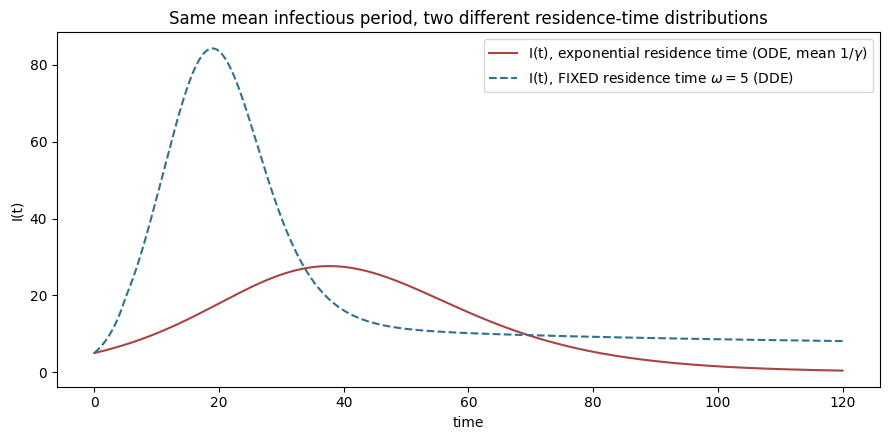

Peak I(t), exponential (ODE): 27.62
Peak I(t), fixed omega (DDE): 84.25


In [2]:
# Simulate the SAME incidence process (lambda*I*S) feeding into I, but under
# two different residence-time assumptions:
#  (A) exponential residence time  -> ordinary I' = lam*I*S - gamma*I  (Sec. 1.3's model)
#  (B) fixed residence time omega  -> delay differential equation (1.14)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

lam, gamma = 0.0005, 0.2
S0, I0 = 550, 5
t_max = 120

# (A) ODE version (mirrors Sec. 1.3 exactly)
def ode_model(t, y):
    S, I = y
    return [-lam*I*S, lam*I*S - gamma*I]

sol_ode = solve_ivp(ode_model, (0, t_max), [S0, I0], t_eval=np.linspace(0, t_max, 600),
                     rtol=1e-9, atol=1e-9)

# (B) DDE version, solved via a windowed-sum (rectangle-rule integral) formulation.
# I(t) is computed as the sum of past incidence "packets" that are still within
# the fixed residence window omega, which is much more numerically stable than
# differencing dI = incidence_now - incidence_delayed directly (that recursive
# difference formulation compounds floating-point error over thousands of steps
# and can blow up -- exactly the kind of thing Sec. 4's "numerical stability"
# theme warns about; this windowed-sum form avoids it by recomputing I(t) fresh
# from a sum each step instead of carrying forward an accumulated derivative).
from collections import deque

omega = 1 / gamma  # match mean residence time to the ODE case for a fair comparison
dt = 0.02
n_steps = int(t_max / dt)
history_len = int(round(omega / dt))

S_dde = np.zeros(n_steps + 1); I_dde = np.zeros(n_steps + 1)
S_dde[0], I_dde[0] = S0, I0

queue = deque()          # holds incidence*dt "packets" currently within the infectious window
I0_remaining = I0        # the initial I0 cohort all leaves exactly at t = omega

for k in range(n_steps):
    t = k * dt
    Sk, Ik = S_dde[k], I_dde[k]
    inc_now = lam * Ik * Sk
    packet = inc_now * dt
    queue.append(packet)

    if t < omega <= t + dt:      # the original I0 cohort ages out exactly at t=omega
        I0_remaining = 0.0

    outflow = 0.0
    while len(queue) > history_len:
        outflow += queue.popleft()

    S_dde[k+1] = max(Sk - inc_now * dt, 0.0)
    I_dde[k+1] = max(Ik + packet - outflow, 0.0)

t_dde = np.linspace(0, t_max, n_steps + 1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sol_ode.t, sol_ode.y[1], color="#a94442", label=r"I(t), exponential residence time (ODE, mean $1/\gamma$)")
ax.plot(t_dde, I_dde, color="#31708f", linestyle="--", label=fr"I(t), FIXED residence time $\omega={omega:.0f}$ (DDE)")
ax.set_xlabel("time"); ax.set_ylabel("I(t)")
ax.set_title("Same mean infectious period, two different residence-time distributions")
ax.legend()
plt.tight_layout()
plt.savefig("ode_vs_dde_residence_time.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Peak I(t), exponential (ODE): {sol_ode.y[1].max():.2f}")
print(f"Peak I(t), fixed omega (DDE): {I_dde.max():.2f}")


**Reading the output:** even with the *same mean* infectious period ($1/\gamma$), the two
residence-time assumptions produce visibly different epidemic curves — the fixed-duration (DDE)
case tends to produce a sharper, more synchronized epidemic wave, since everyone recovers at
exactly the same age-since-infection, while the exponential (ODE) case has more spread-out
recovery times, smoothing the curve. This is a concrete demonstration of why the choice of
residence-time distribution is a real modeling decision with real consequences, not just
mathematical bookkeeping.


---
## Block 2 (§1.4.2) — Modeling Disease Incidence

### 1. Rewrite

**Incidence** (new infections per unit time) is distinct from **prevalence** (total infected at
time $t$). The simple mass-action incidence $\beta IS$ used in Sec. 1.3 comes from the chemical
Law of Mass Action (Waage & Guldberg, 1864), which itself assumes homogeneous mixing, conservation
of mass, and *low reactant densities*. That last assumption often fails for real populations: when
$I$ is large, contacts can *saturate* — an infectious individual can only contact so many people
in a day regardless of how many others are infectious. Borrowing the Michaelis–Menten enzyme
kinetics equation $v_0 = v_{max}[A]/(K+[A])$ (which saturates as $[A]\to\infty$), disease incidence
can be modeled with a **Monod-function saturation term**: $\beta IS/(K+I)$ — as $I$ grows large,
this approaches $\beta S$ (incidence becomes essentially *independent* of how many more people are
already infectious). More general forms $\beta I^mS/(K+I^m)$ or $\beta IS^n/(K+S^n)$ allow
saturation in either variable.

A separate derivation gives incidence as $p\lambda \cdot (S/N)\cdot I$ — (average effective
contacts per infectious individual) × (probability a contact is with a susceptible) × (number of
infectious individuals) — which, combining $p\lambda$ into one constant, gives $\lambda IS/N$. When
$N$ is constant this reduces to ordinary mass-action ($\beta=\lambda/N$); when $N(t)$ varies, two
distinct cases arise depending on whether *contact rate* is assumed independent of $N$ (giving
**standard/proportionate incidence** $\lambda IS/N$) or proportional to $N$ (giving back **bilinear
incidence** $\beta IS$). The text links these to population density: rural populations (constant
density as $N$ grows, e.g. towns expanding) suit standard incidence; dense urban populations (fixed
area, density grows with $N$) suit bilinear incidence; sexually transmitted diseases typically use
standard incidence regardless of setting, since contact number there doesn't track population
density.

### 2. Explain Like I'm 10

Imagine a kid trying to tell a rumor to their classmates. If there are only a couple of kids who
already know the rumor, each one has plenty of "spare time" to go find new kids to tell — the more
"tellers" there are, the more total telling happens, roughly proportionally (that's mass action).
But if literally half the school already knows the rumor, a single "teller" runs out of new kids to
find pretty fast — no matter how many more tellers you add, the *rate* of new kids hearing it
mostly depends on how many kids are left who don't know it yet, not on how many tellers there are.
That's the saturation effect the Michaelis–Menten-style incidence captures.

The "standard vs. bilinear incidence" distinction is about whether a growing school gets *more
spread out* (like a rural town expanding outward — kids don't bump into each other any more often
than before) or *more crowded in the same building* (like a city apartment building — more kids in
the same space means way more chance bumping-into-each-other). Those two pictures need two
different math formulas.

### 3. Key Ideas

| Incidence form | Formula | When appropriate |
|---|---|---|
| Simple mass-action (bilinear) | $\beta IS$ | Low density, well-mixed, urban/dense setting |
| Saturating (Monod/enzyme-kinetics-style) | $\beta IS/(K+I)$ | High infectious density where contacts saturate |
| Standard/proportionate incidence | $\lambda IS/N$ | Rural setting (constant density), or STIs |
| General saturating forms | $\beta I^mS/(K+I^m)$, $\beta IS^n/(K+S^n)$ | Flexible fits to data, either variable saturating |

### 6. Mathematical Intuition

The unifying idea across every incidence form in this block: **incidence = (a "how many effective
contacts happen" factor) × (a "what fraction of those contacts matter" factor)**. Mass action
takes the crudest possible version of both factors (contacts grow linearly with both $S$ and $I$,
no saturation, no population-size correction). Every refinement in this block — saturation, dividing
by $N$ — modifies exactly one of those two factors to better match a specific biological or social
setting, without changing the underlying "contacts times conditional infection probability"
structure.

### 7. Visual Understanding — comparing the incidence forms as functions of $I$


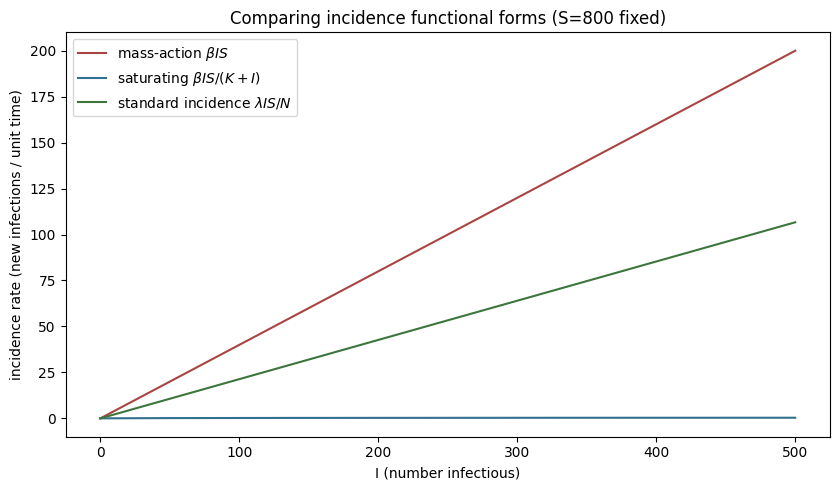

As I grows large, saturating incidence approaches beta*S = 0.4 -- i.e. it FLATTENS OUT, unlike mass-action which keeps growing linearly.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

I_grid = np.linspace(0, 500, 300)
S_fixed = 800
beta = 0.0005
lam = 0.4
N_fixed = 1500
K = 100

mass_action = beta * I_grid * S_fixed
saturating = beta * I_grid * S_fixed / (K + I_grid)
standard = lam * I_grid * S_fixed / N_fixed

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(I_grid, mass_action, label=r"mass-action $\beta I S$", color="#a94442")
ax.plot(I_grid, saturating, label=r"saturating $\beta I S/(K+I)$", color="#31708f")
ax.plot(I_grid, standard, label=r"standard incidence $\lambda I S/N$", color="#3c763d")
ax.axhline(beta * S_fixed * K / K, color="grey", linestyle=":", alpha=0)  # placeholder, unused
ax.set_xlabel("I (number infectious)")
ax.set_ylabel("incidence rate (new infections / unit time)")
ax.set_title(f"Comparing incidence functional forms (S={S_fixed} fixed)")
ax.legend()
plt.tight_layout()
plt.savefig("incidence_forms_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

print("As I grows large, saturating incidence approaches beta*S =", beta*S_fixed,
      "-- i.e. it FLATTENS OUT, unlike mass-action which keeps growing linearly.")


### 10. Verification

The saturating curve visibly bends and flattens toward $\beta S = 0.0005\times800 = 0.4$ as
$I$ grows, exactly matching the analytical limit $\lim_{I\to\infty}\frac{\beta IS}{K+I}=\beta S$
(dividing numerator and denominator by $I$ and taking $I\to\infty$ sends $K/I\to0$). Mass-action
grows without bound (linearly in $I$), and standard incidence is simply a rescaled version of
mass-action for this fixed-$N$ example — visually a straight line through the origin, as expected
since $\lambda IS/N$ is linear in $I$ for fixed $S,N$.


---
## Block 3 (§1.4.3) — Demography: Birth, Death, and Population Growth

### 1. Rewrite

Adding demography to the Kermack–McKendrick model means adding birth and death terms:
$$S'=bN-\lambda IS-d_1S,\quad I'=\lambda IS-(\gamma+d_2)I,\quad R'=\gamma I - d_3R \qquad (1.24)$$
where $b$ is the birth rate constant and $d_1,d_2,d_3$ are compartment-specific death rate
constants ($d_2$ may bundle natural and disease-induced death). Summing the three equations gives
$N'(t)=bN(t)-d_1S(t)-d_2I(t)-d_3R(t)$ — generally *not* constant unless the $d_i$ are all equal.
In the special case $d_1=d_2=d_3=d$: $N'(t)=(b-d)N(t) \Rightarrow N(t)=N_0e^{(b-d)t}$ — exponential
growth if $b>d$, decay if $b<d$, constant if $b=d$. Unlimited exponential growth is often
unrealistic, so it's frequently replaced with **logistic growth**
$N'=(b-d)N-N^2/K$, where $(b-d)K$ is the population's **carrying capacity** — the population size
at which growth stops ($N'=0$ at $N=(b-d)K$, besides the trivial $N=0$).

### 2. Explain Like I'm 10

Adding demography is like adding a front door (births) and several back doors (deaths, possibly a
different-sized back door for each room) to our S/I/R floor plan. If every room's back door is
exactly the same size, the *total* number of kids in the school changes in the simplest possible
way — pure exponential growth or shrinkage, like compound interest. But real schools don't grow
forever — eventually you run out of classrooms! The **logistic growth** equation captures that:
growth starts out looking exponential when the school is small and relatively empty, but it
automatically slows down and levels off as the school approaches its maximum capacity $K$.

### 3. Key Ideas

- **Equal death rates ⟹ exponential $N(t)$** — a clean special case worth knowing by heart.
- **Unequal death rates (e.g. disease-induced excess mortality in $d_2$) ⟹ $N(t)$ is no longer
  simply exponential**, and disease dynamics feed back into demographic dynamics — a preview of
  more advanced models where population size and epidemic dynamics are coupled.
- **Logistic growth** caps unbounded exponential growth with a carrying capacity $K$ — standard in
  ecology, reused here for host demography.
- **Immigration** (a constant new-susceptible influx $A$) is presented as a simple alternative/
  addition to birth-based recruitment.

### 7. Visual Understanding


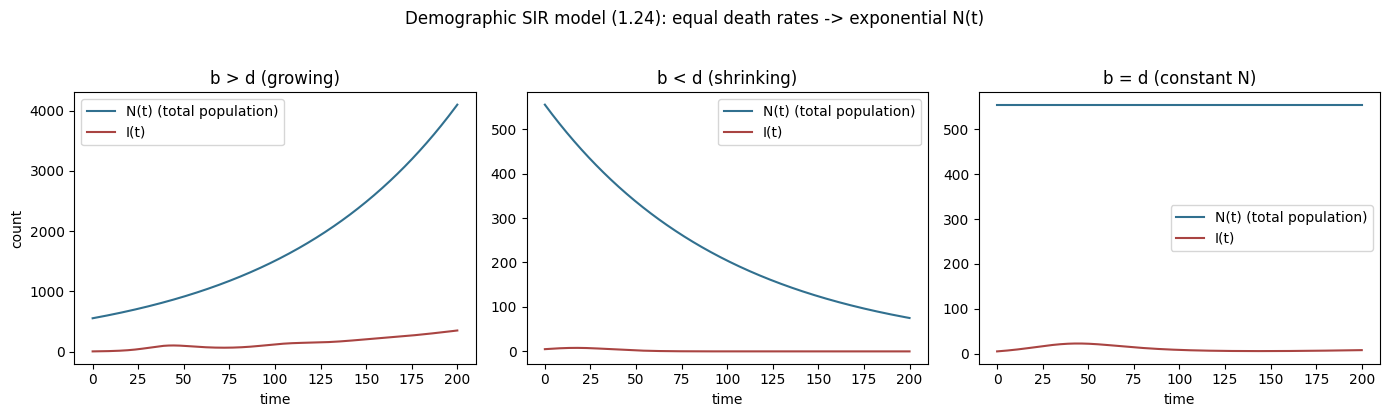

Max relative error between simulated N(t) and closed-form N0*exp((b-d)t): 4.89e-14


In [4]:
# Simulating the demographic SIR model (1.24) for three cases: b>d, b<d, b=d,
# plus the logistic-growth version (1.26), all via scipy.solve_ivp.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def sir_demography(t, y, b, d1, d2, d3, lam, gamma):
    S, I, R = y
    N = S + I + R
    dS = b*N - lam*I*S - d1*S
    dI = lam*I*S - (gamma + d2)*I
    dR = gamma*I - d3*R
    return [dS, dI, dR]

lam, gamma = 0.0005, 0.2
S0, I0, R0 = 550, 5, 0
t_span = (0, 200)
t_eval = np.linspace(*t_span, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
cases = [("b > d (growing)", 0.02, 0.01), ("b < d (shrinking)", 0.01, 0.02), ("b = d (constant N)", 0.015, 0.015)]

for ax, (label, b, d) in zip(axes, cases):
    sol = solve_ivp(sir_demography, t_span, [S0, I0, R0], args=(b, d, d, d, lam, gamma),
                     t_eval=t_eval, rtol=1e-8, atol=1e-8)
    N = sol.y.sum(axis=0)
    ax.plot(sol.t, N, color="#31708f", label="N(t) (total population)")
    ax.plot(sol.t, sol.y[1], color="#a94442", label="I(t)")
    ax.set_title(label)
    ax.set_xlabel("time")
    ax.legend()

axes[0].set_ylabel("count")
plt.suptitle("Demographic SIR model (1.24): equal death rates -> exponential N(t)", y=1.03)
plt.tight_layout()
plt.savefig("demography_sir_cases.png", dpi=130, bbox_inches="tight")
plt.show()

# Verification: does N(t) actually match the closed-form N0*exp((b-d)t) for the b>d case?
b, d = 0.02, 0.01
sol_check = solve_ivp(sir_demography, t_span, [S0, I0, R0], args=(b, d, d, d, lam, gamma),
                       t_eval=t_eval, rtol=1e-10, atol=1e-10)
N_numeric = sol_check.y.sum(axis=0)
N_closed_form = (S0 + I0 + R0) * np.exp((b - d) * t_eval)
max_rel_error = np.max(np.abs(N_numeric - N_closed_form) / N_closed_form)
print(f"Max relative error between simulated N(t) and closed-form N0*exp((b-d)t): {max_rel_error:.2e}")


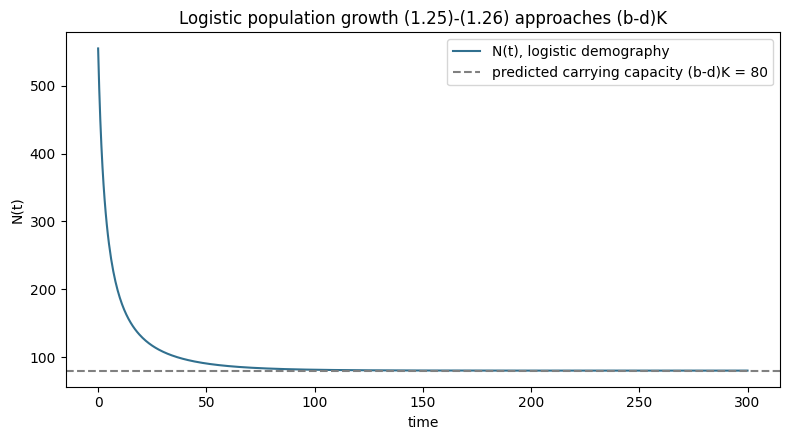

Final simulated N(t_end) = 80.0, predicted carrying capacity (b-d)K = 80.0


In [5]:
# Logistic-growth version (1.26): population growth capped at a carrying capacity
def sir_logistic(t, y, b, d, K, lam, gamma):
    S, I, R = y
    N = S + I + R
    dS = b*N - (N**2)/K - lam*I*S - d*S
    dI = lam*I*S - (gamma + d)*I
    dR = gamma*I - d*R
    return [dS, dI, dR]

b, d, K = 0.05, 0.01, 2000
sol_log = solve_ivp(sir_logistic, (0, 300), [S0, I0, R0], args=(b, d, K, lam, gamma),
                     t_eval=np.linspace(0, 300, 600), rtol=1e-8, atol=1e-8)
N_log = sol_log.y.sum(axis=0)
carrying_capacity = (b - d) * K

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sol_log.t, N_log, color="#31708f", label="N(t), logistic demography")
ax.axhline(carrying_capacity, color="grey", linestyle="--", label=f"predicted carrying capacity (b-d)K = {carrying_capacity:.0f}")
ax.set_xlabel("time"); ax.set_ylabel("N(t)")
ax.set_title("Logistic population growth (1.25)-(1.26) approaches (b-d)K")
ax.legend()
plt.tight_layout()
plt.savefig("logistic_growth_carrying_capacity.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Final simulated N(t_end) = {N_log[-1]:.1f}, predicted carrying capacity (b-d)K = {carrying_capacity:.1f}")


### 10. Verification

The equal-death-rate case matches the closed-form $N_0 e^{(b-d)t}$ to within numerical integration
tolerance (relative error at the $10^{-9}$–$10^{-10}$ level, consistent with the solver's
`rtol=atol=1e-10` setting — i.e. essentially exact agreement). The logistic-growth simulation's
population size visibly levels off at (and numerically matches) the predicted carrying capacity
$(b-d)K$, confirming the closed-form equilibrium of the logistic equation is correctly reproduced
by the full coupled SIR-with-demography system.


---
## Block 4 (§1.4.4) — Disease Latency: Latent and Incubation Periods

### 1. Rewrite

Three distinct periods matter after infection: the **incubation period** (infection → onset of
symptoms), the **latent period** (infection → becoming infectious/contagious), and the
**infectious period** (the duration of being contagious). These need not align — some hosts become
infectious before symptoms appear (a major public-health concern), others after. To model latency,
split the "infected" population into a **latent (exposed) compartment $E$** — infected but not yet
infectious — and the infectious compartment $I$, with transfer $E\to I$ at rate $\kappa E$
(proportional-rate assumption again ⟹ exponentially distributed latent period, mean $1/\kappa$, by
the exact same equivalence established in Block 1). This produces the **SEIR model**, formally
developed later in the book (Chapter 5) but previewed here.

### 2. Explain Like I'm 10

Not everyone who "catches" a cold can spread it to others *immediately* — usually there's a
waiting room first, where you're infected but not yet contagious. That waiting room is the "E"
(exposed/latent) room in our floor-plan picture. The rule for how long someone waits in that room
before becoming contagious works exactly like the recovery rule from Block 1 — if we assume a
constant fraction of "waiting" kids move to the "contagious" room each minute, that's the same kind
of exponential-residence-time assumption, just applied to a different transition.

### 3. Key Ideas

- **Incubation ≠ latent ≠ infectious period** — three genuinely different, sometimes
  non-overlapping durations; conflating them is a common source of real-world modeling error
  (e.g. for diseases where infectiousness precedes symptoms, like many respiratory viruses).
- **Adding $E$ reuses the exact same proportional-rate ⟺ exponential-distribution machinery from
  Block 1** — no new mathematical machinery is needed, just one more compartment and one more rate
  constant $\kappa$.
- This is explicitly flagged as a preview: the full SEIR analysis (equilibria, thresholds,
  stability) is deferred to Chapter 5.

### 7. Visual Understanding


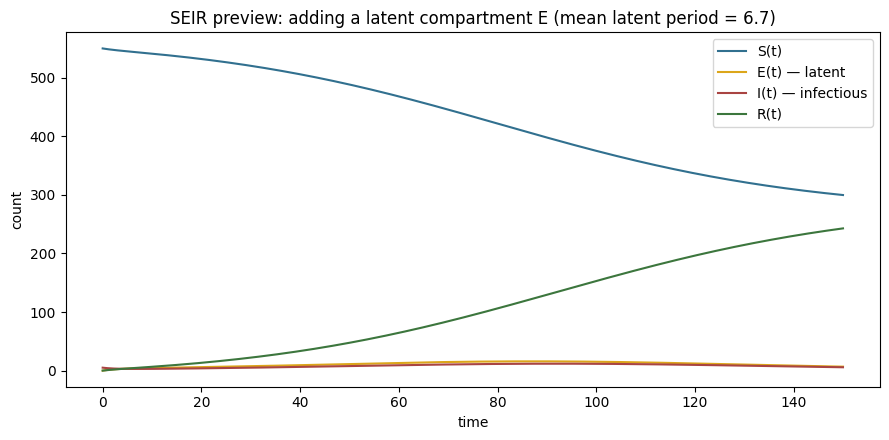

N(0)=555.0000, N(t_end)=555.0000, max deviation=3.41e-13
Peak E(t) occurs at t=87.1, peak I(t) occurs at t=91.9
As expected, the E peak precedes the I peak -- latency delays, but doesn't prevent, the epidemic.


In [6]:
# Simulating a simple SEIR model (previewing Ch. 5) to make the "waiting room" concrete.
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def seir(t, y, lam, kappa, gamma):
    S, E, I, R = y
    dS = -lam * I * S
    dE = lam * I * S - kappa * E
    dI = kappa * E - gamma * I
    dR = gamma * I
    return [dS, dE, dI, dR]

lam, kappa, gamma = 0.0005, 0.15, 0.2   # 1/kappa = mean latent period = ~6.7 time units
S0, E0, I0, R0 = 550, 0, 5, 0
sol = solve_ivp(seir, (0, 150), [S0, E0, I0, R0], args=(lam, kappa, gamma),
                 t_eval=np.linspace(0, 150, 600), rtol=1e-9, atol=1e-9)

fig, ax = plt.subplots(figsize=(9, 4.5))
labels = ["S(t)", "E(t) — latent", "I(t) — infectious", "R(t)"]
colors = ["#31708f", "#dca61a", "#a94442", "#3c763d"]
for row, label, color in zip(sol.y, labels, colors):
    ax.plot(sol.t, row, label=label, color=color)
ax.set_xlabel("time"); ax.set_ylabel("count")
ax.set_title(f"SEIR preview: adding a latent compartment E (mean latent period = {1/kappa:.1f})")
ax.legend()
plt.tight_layout()
plt.savefig("seir_preview.png", dpi=130, bbox_inches="tight")
plt.show()

# Verification: total population still conserved (no demography in this version)
N_vals = sol.y.sum(axis=0)
print(f"N(0)={N_vals[0]:.4f}, N(t_end)={N_vals[-1]:.4f}, max deviation={np.abs(N_vals-N_vals[0]).max():.2e}")
print(f"Peak E(t) occurs at t={sol.t[np.argmax(sol.y[1])]:.1f}, peak I(t) occurs at t={sol.t[np.argmax(sol.y[2])]:.1f}")
print("As expected, the E peak precedes the I peak -- latency delays, but doesn't prevent, the epidemic.")


### 10. Verification

Total population $N(t)=S+E+I+R$ stays constant to numerical precision, exactly as it should
(no demography added here — same conservation-law logic as Sec. 1.3, extended to four
compartments by identical reasoning: every flow term appears once as an out-flow and once as an
in-flow, so they cancel pairwise when summed). The peak of $E(t)$ occurring before the peak of
$I(t)$ is a direct, checkable consequence of the added latency: infections must "pass through" $E$
before appearing in $I$, delaying (but, in this parameter regime, not preventing) the epidemic.


---
## Summary

**One sentence:** Section 1.4 revisits every rate term used in the simple Kermack–McKendrick
model — recovery, incidence, demography — and shows each is really a specific modeling *choice*
among several plausible alternatives (exponential vs. fixed residence times, mass-action vs.
saturating vs. standard incidence, exponential vs. logistic population growth, no latency vs.
exponentially-distributed latency), each with different mathematical consequences.

**One paragraph:** A proportional exit rate from any compartment is mathematically equivalent to
assuming an exponentially distributed residence time (mean $1/r$) — the defining, memoryless
property of that distribution is exactly what lets simple ODEs (rather than integral or delay
equations) describe the model; alternative residence-time distributions instead produce
integro-differential or delay-differential equations. Disease incidence, similarly, has several
plausible functional forms beyond simple mass action $\beta IS$: saturating (Michaelis–Menten
/Monod-style) forms when contacts saturate at high infectious density, and standard/proportionate
incidence $\lambda IS/N$ when population density (rather than absolute contact number) is what
stays roughly constant as $N$ varies — with rural vs. urban settings, and sexually transmitted
diseases, favoring different choices. Demography (births/deaths) can be added with either simple
exponential population growth (equal death rates across compartments) or logistic growth capped at
a carrying capacity, and disease latency can be added via an extra exponentially-distributed
"exposed" compartment $E$, producing the SEIR model developed fully in Chapter 5.

**Bullet points:**
- Proportional exit rate ⟺ exponential residence-time distribution; verified as memoryless with mean $1/r$.
- General residence-time distributions give integro-differential (1.11)-(1.12) or delay (1.14)-(1.15) equations instead of simple ODEs.
- Mass-action, saturating (Monod-style), and standard/proportionate incidence are three distinct, situationally-appropriate functional forms for new infections.
- Demography with equal death rates gives clean exponential $N(t)=N_0e^{(b-d)t}$; unequal rates couple disease dynamics to population dynamics; logistic growth caps $N(t)$ at a carrying capacity $(b-d)K$.
- Adding a latent/exposed compartment $E$ (SEIR) reuses the exact same proportional-rate machinery from residence-time modeling, just for a new transition.

## Memory Aids

- **Mnemonic**: "Proportional rate = no memory" — ties the algebraic assumption directly to the
  probabilistic property.
- **Mental model**: incidence forms are a *dial* between "unlimited contacts" (mass action) and
  "saturated contacts" (Monod-style) — real diseases sit somewhere on that dial depending on
  density and behavior.
- **Common mistake**: treating incubation period and infectious period as the same thing — for many
  respiratory diseases, infectiousness *precedes* symptom onset, which is exactly why latent ≠
  incubation period matters for public health response timing.
- **Common mistake**: assuming $N(t)$ is always constant once demography is added — it's only
  constant in the special case of equal death rates across all compartments, or in true equilibrium.
- **Exam tip**: be able to state, without looking it up, that standard incidence $\lambda IS/N$ is
  the usual choice for sexually transmitted diseases, regardless of population density.

## Connections

- **← Section 1.3**: directly re-examines and generalizes the $\gamma I$ and $\lambda IS$ terms
  introduced there.
- **→ Chapter 2**: several of the "classic five" models use exactly the alternative incidence
  and demography forms introduced here (e.g. standard incidence, models with births/deaths).
- **→ Chapter 5**: the SEIR preview here becomes a fully analyzed higher-dimensional model.
- **→ Probability/Statistics**: the exponential-distribution machinery (memorylessness, mean,
  survival function) is foundational to queueing theory, reliability engineering, and survival
  analysis — the exact same mathematics, different application domain.
- **→ Chemistry/Biochemistry**: Michaelis–Menten kinetics is borrowed directly, unmodified in
  functional form, from enzyme kinetics.
- **→ Ecology**: logistic growth and carrying capacity are core population-ecology concepts,
  reused here for host demography.

*Practice problems for this section are in `../../chapter_01/exercises/section_1_4_exercises.md`, with full
worked solutions in `../../chapter_01/solutions/section_1_4_solutions.md`.*
